In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, 
    f1_score, fbeta_score, precision_score, recall_score,
    matthews_corrcoef, brier_score_loss, RocCurveDisplay, roc_auc_score, make_scorer
)
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.calibration import CalibrationDisplay
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier

# Data Ingestion and Cleaning

Goal: We want to maximize amount of money saved by Big G. A full derate costs around \\$4000 for towing, plus the cost of
repairs. The cost of a false positive prediction is about \\$500 due to having the truck oﬀ the road and serviced unnecessarily. Thus, we'll want to optimize our model for recall.

We want to attempt to predict an idle derate at least **2 hours** before it occurs.

In [2]:
faults = pd.read_csv("../data/J1939Faults.csv")

# Dropping columns that are not relevant
faults_clean = faults.drop(columns=['ecuSoftwareVersion', 'ecuSerialNumber', 'ecuModel', 'ecuMake', 'ecuSource', 'MCTNumber', 'ESS_Id', 'actionDescription', 'faultValue'])

faults_clean.head()

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_45816/4289917023.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  faults = pd.read_csv("../data/J1939Faults.csv")


,RecordID,EventTimeStamp,eventDescription,spn,fmi,active,activeTransitionCount,EquipmentID,Latitude,Longitude,LocationTimeStamp
0,1,2015-02-21 10:47:13.000,Low (Severity Low) Engine Coolant Level,111,17,True,2,1439,38.857638,-84.626851,2015-02-21 11:34:25.000
1,2,2015-02-21 11:34:34.000,NaN,629,12,True,127,1439,38.857638,-84.626851,2015-02-21 11:35:10.000
2,3,2015-02-21 11:35:31.000,Incorrect Data Steering Wheel Angle,1807,2,False,127,1369,41.421250,-87.767361,2015-02-21 11:35:26.000
3,4,2015-02-21 11:35:33.000,Incorrect Data Steering Wheel Angle,1807,2,True,127,1369,41.421018,-87.767361,2015-02-21 11:36:08.000
4,5,2015-02-21 11:39:41.000,NaN,4364,17,False,2,1674,38.416481,-89.442638,2015-02-21 11:39:37.000


Looking at the first record, here is a breakdown of the important values.

* ESS_Id, actionDescription, ecuSoftwareVersion, ecuSerialNumber, ecuModel, ecuMake, ecuSource, faultValue, and MCTNumber are unlikely to provide any predictive value.
* We can see the time of the event in the **EventTimeStamp** column. Note that this may be different from the **LocationTimeStamp** value, which indicates when the Latitude/Longitude values were recorded.
* The **spn** and **fmi** columns together indicate the type of fault, and there may be a description of that fault in the **eventDescription** column, although this column is sometimes missing.
* Faults are recorded when the light goes on and when it goes off, which is indicated by the **active** column, with True indicating the light turning on and False indicating turning off. The number of times the code has been set or unset is in the **faultValue** column, although this value can be unreliable. 
* Each truck has an identifier, the **EquipmentID** value.
* Each record can be linked to the on-board diagnostics data through the **RecordID** column.

Filtering out vehicles that are likely being serviced: (We'll come back to this)

Service stations are at (36.0666667, -86.4347222), (35.5883333, -86.4438888), and (36.1950, -83.174722)

In [3]:
# Creating a dataframe with service station locations
stations = pd.DataFrame({'lat':[36.0666667, 35.5883333, 36.1950], 'lon':[-86.4347222, -86.4438888, -83.174722]})

In [4]:
# From this article: https://kanoki.org/2019/12/27/how-to-calculate-distance-in-python-and-pandas-using-scipy-spatial-and-distance-functions/
# Vectorized Haversine formula
def haversine_vectorize(lon1, lat1, lon2, lat2):

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    newlon = lon2 - lon1
    newlat = lat2 - lat1

    haver_formula = np.sin(newlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(newlon/2.0)**2

    dist = 2 * np.arcsin(np.sqrt(haver_formula ))
    mi = 3958 * dist 
    return mi

faults_clean['dist_from_stat_1'] = haversine_vectorize(stations.loc[0]['lon'], stations.loc[0]['lat'], faults_clean['Longitude'], faults_clean['Latitude'])
faults_clean['dist_from_stat_2'] = haversine_vectorize(stations.loc[1]['lon'], stations.loc[1]['lat'], faults_clean['Longitude'], faults_clean['Latitude'])
faults_clean['dist_from_stat_3'] = haversine_vectorize(stations.loc[2]['lon'], stations.loc[2]['lat'], faults_clean['Longitude'], faults_clean['Latitude'])


In [5]:
faults_clean.head()

,RecordID,EventTimeStamp,eventDescription,spn,fmi,active,activeTransitionCount,EquipmentID,Latitude,Longitude,LocationTimeStamp,dist_from_stat_1,dist_from_stat_2,dist_from_stat_3
0,1,2015-02-21 10:47:13.000,Low (Severity Low) Engine Coolant Level,111,17,True,2,1439,38.857638,-84.626851,2015-02-21 11:34:25.000,216.779342,246.957471,200.394786
1,2,2015-02-21 11:34:34.000,NaN,629,12,True,127,1439,38.857638,-84.626851,2015-02-21 11:35:10.000,216.779342,246.957471,200.394786
2,3,2015-02-21 11:35:31.000,Incorrect Data Steering Wheel Angle,1807,2,False,127,1369,41.421250,-87.767361,2015-02-21 11:35:26.000,376.784933,409.225406,437.407343
3,4,2015-02-21 11:35:33.000,Incorrect Data Steering Wheel Angle,1807,2,True,127,1369,41.421018,-87.767361,2015-02-21 11:36:08.000,376.769223,409.209647,437.394356
4,5,2015-02-21 11:39:41.000,NaN,4364,17,False,2,1674,38.416481,-89.442638,2015-02-21 11:39:37.000,231.732035,255.969764,376.935409


In [6]:
faults_clean.shape

(1187335, 14)

In [7]:
# Only keep rows that are more than 1 mile away from all 3 of the service stations
faults_clean = faults_clean[(faults_clean['dist_from_stat_1'] > 1) & (faults_clean['dist_from_stat_2'] > 1) & (faults_clean['dist_from_stat_3'] > 1)]


In [8]:
# Drop intermediate columns that we don't need
faults_clean = faults_clean.drop(columns=['dist_from_stat_1','dist_from_stat_2','dist_from_stat_3'])

In [9]:
faults_clean.shape

(1055071, 11)

In [10]:
(1187335-1055071)/1187335

0.11139568866410912

Looks like about 11% of our dataset was collected within 1 mile of a service station.

In [11]:
diagnostics = pd.read_csv("../data/VehicleDiagnosticOnboardData.csv")

diagnostics.head()

,Id,Name,Value,FaultId
0,1,IgnStatus,False,1
1,2,EngineOilPressure,0,1
2,3,EngineOilTemperature,96.74375,1
3,4,TurboBoostPressure,0,1
4,5,EngineLoad,11,1


Pivoting diagnostic onboard data by fault ID so that it's easier to merge. 

In [12]:
diagnostics[diagnostics['FaultId']==2]

,Id,Name,Value,FaultId
21,22,IgnStatus,True,2
22,23,LampStatus,1279,2


In [13]:
diagnostics_pivoted = diagnostics.pivot(index='FaultId', columns='Name', values='Value')

In [14]:
diagnostics_pivoted.head()

Name,AcceleratorPedal,BarometricPressure,CruiseControlActive,CruiseControlSetSpeed,DistanceLtd,EngineCoolantTemperature,EngineLoad,EngineOilPressure,EngineOilTemperature,EngineRpm,...,FuelTemperature,IgnStatus,IntakeManifoldTemperature,LampStatus,ParkingBrake,ServiceDistance,Speed,SwitchedBatteryVoltage,Throttle,TurboBoostPressure
FaultId,,,,,,,,,,,,,,,,,,,,,
1,0,14.21,False,66.48672,423178.7,100.4,11,0,96.74375,0,...,NaN,False,78.8,1023,True,NaN,0,3276.75,NaN,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,True,NaN,1279,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1279,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,True,NaN,1279,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,16639,NaN,NaN,NaN,NaN,NaN,NaN


To merge diagnostic info with fault code info, we'll match up the **RecordID** and **FaultId**.

In [15]:
faults_full = pd.merge(faults_clean, diagnostics_pivoted, left_on='RecordID', right_on='FaultId', how='inner')

faults_full.head()

,RecordID,EventTimeStamp,eventDescription,spn,fmi,active,activeTransitionCount,EquipmentID,Latitude,Longitude,...,FuelTemperature,IgnStatus,IntakeManifoldTemperature,LampStatus,ParkingBrake,ServiceDistance,Speed,SwitchedBatteryVoltage,Throttle,TurboBoostPressure
0,1,2015-02-21 10:47:13.000,Low (Severity Low) Engine Coolant Level,111,17,True,2,1439,38.857638,-84.626851,...,NaN,False,78.8,1023,True,NaN,0,3276.75,NaN,0
1,2,2015-02-21 11:34:34.000,NaN,629,12,True,127,1439,38.857638,-84.626851,...,NaN,True,NaN,1279,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2015-02-21 11:35:31.000,Incorrect Data Steering Wheel Angle,1807,2,False,127,1369,41.421250,-87.767361,...,NaN,NaN,NaN,1279,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2015-02-21 11:35:33.000,Incorrect Data Steering Wheel Angle,1807,2,True,127,1369,41.421018,-87.767361,...,NaN,True,NaN,1279,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2015-02-21 11:39:41.000,NaN,4364,17,False,2,1674,38.416481,-89.442638,...,NaN,NaN,NaN,16639,NaN,NaN,NaN,NaN,NaN,NaN


# Creating target column

Our plan will be to make 3 different target columns: 
* Derate in 6 hours
* Derate in 12 hours
* Derate in 24 hours

Then, we'll fit our model on each of the 3 target columns and see which model is most predictive.

The idea is to give the vehicle operator enough warning so that they have enough time to drive to a service station. 0-2 hours of warning probably isn't enough time, so we'll discard those rows when testing our model. As we increase the window larger and larger, we'll probably lose some predictive power. So we'll try to find the sweet spot by evaluating several different time windows.

In [16]:
# Creating a new column to mark whether the fault represents a full derate
faults_full['derate_flag'] = ((faults_full["spn"] == 5246) & (faults_full["active"] == True)).astype('int')

In [17]:
# Converting EventTimeStamp to datetime 
faults_full['EventTimeStamp']= pd.to_datetime(faults_full['EventTimeStamp'])

In [18]:
# Running into an issue with duplicated EquipmentID/EventTimeStamp. 
# The .rolling method can't handle the duplicated EquipmentID and EventTimeStamp columns.
# We'll need to de-duplicate before we apply .rolling
# By taking the max of 'derate_flag', we're ensuring that for each EquipmentID/EventTimeStamp combination, 
#       we're capturing whether at least one derate occurred for that vehicle at that time (if multiple faults occurred simultaneously)
faults_dedup = faults_full.groupby(['EquipmentID', 'EventTimeStamp']).max('derate_flag').reset_index()

In [19]:
faults_dedup.head()

,EquipmentID,EventTimeStamp,RecordID,spn,fmi,active,activeTransitionCount,Latitude,Longitude,derate_flag
0,301,2015-05-11 13:11:20,49415,639,2,True,127,36.189398,-82.795601,0
1,301,2015-05-13 08:22:32,51363,596,31,True,3,35.872500,-84.475648,0
2,301,2015-05-18 09:34:05,57330,3226,10,True,6,35.972870,-83.920555,0
3,301,2015-05-21 13:57:35,61706,639,2,True,127,36.384953,-86.478379,0
4,301,2015-05-21 14:54:32,61801,639,2,False,127,36.384814,-86.478379,0


In [20]:
# Ensure faults data is sorted by EventTimeStamp
# By sorting the EventTimeStamp in descending order, we're ensuring that we are rolling forwards in time (since .rolling looks at preceding rows)
faults_dedup = faults_dedup.sort_values(by='EventTimeStamp', ascending=False)

# Then we're applying the .rolling method with a certain time window and taking the rolling count of derates.
# The new columns are indicating the total number of derates that happened in the next certain time window for the given vehicle.
target = faults_dedup[['EquipmentID','EventTimeStamp']].copy()
                       
target['total_derates_2_hr'] = faults_dedup.groupby('EquipmentID').rolling(window='2h', on='EventTimeStamp')['derate_flag'].sum().reset_index(drop=True)
target['total_derates_6_hr'] = faults_dedup.groupby('EquipmentID').rolling(window='6h', on='EventTimeStamp')['derate_flag'].sum().reset_index(drop=True)
target['total_derates_12_hr'] = faults_dedup.groupby('EquipmentID').rolling(window='12h', on='EventTimeStamp')['derate_flag'].sum().reset_index(drop=True)
target['total_derates_24_hr'] = faults_dedup.groupby('EquipmentID').rolling(window='24h', on='EventTimeStamp')['derate_flag'].sum().reset_index(drop=True)
# Also creating a column capturing the total number of faults in the past hour, since it seems likely that multiple faults might fire right before a derate
target['faults_in_last_hr'] = faults_dedup.groupby('EquipmentID').rolling(window='1h', on='EventTimeStamp')['spn'].count().reset_index(drop=True)

# If there were 1 or more derates in the given time range, we mark it with "1"; otherwise, "0". Rows within 2 hours of a derate get marked with a 2 since they are their own class.
target['derate_6_hr'] = np.where(target['total_derates_2_hr'] > 0, 2,
                        np.where(target['total_derates_6_hr'] - target['total_derates_2_hr'] > 0, 1, 0))

target['derate_12_hr'] = np.where(target['total_derates_2_hr'] > 0, 2,
                        np.where(target['total_derates_12_hr'] - target['total_derates_2_hr'] > 0, 1, 0))

target['derate_24_hr'] = np.where(target['total_derates_2_hr'] > 0, 2,
                        np.where(target['total_derates_24_hr'] - target['total_derates_2_hr'] > 0, 1, 0))


In [21]:
# Drop intermediate columns that we don't need
target = target.drop(columns=['total_derates_2_hr','total_derates_6_hr','total_derates_12_hr','total_derates_24_hr'])

In [22]:
# Next, we'll merge the new columns into the original DataFrame, merging on EventTimeStamp and EquipmentID
# Any duplicate EventTimeStamp/EquipmentID combinations will have the same value in the target column
faults_full = pd.merge(target, faults_full, on=['EventTimeStamp','EquipmentID'], how='inner')

# Ensure faults_full is sorted in order of EventTimeStamp
faults_full = faults_full.sort_values(by='EventTimeStamp')

# Exploratory data analysis

Looking at spn/fmi by derate status:

In [23]:
fmi_counts = pd.crosstab(
    faults_full['fmi'],
    faults_full['derate_flag']
)

fmi_counts.columns = [
    'Non_Derate_Count',
    'Derate_Count'
]

fmi_counts.sort_values(by='Derate_Count', ascending=False)

,Non_Derate_Count,Derate_Count
fmi,,
0,25611,329
16,7270,79
15,18546,54
19,4289,32
14,10098,4
1,17876,0
29,8,0
23,377,0
22,4,0


In [24]:
spn_counts = pd.crosstab(
    faults_full['spn'],
    faults_full['derate_flag']
)

spn_counts.columns = [
    'Non_Derate_Count',
    'Derate_Count'
]

spn_counts.sort_values(by='Derate_Count', ascending=False)

,Non_Derate_Count,Derate_Count
spn,,
5246,438,498
3703,120,0
4376,126,0
4375,221,0
4364,1948,0
...,...,...
906,5,0
905,148,0
904,1,0


In [25]:
# Dropping columns we won't need for our model
faults_full = faults_full.drop(columns=['Latitude','Longitude','RecordID','LocationTimeStamp','eventDescription'])

Exploring missing data:

In [26]:
# Looking at nan proportions overall 
faults_full.isnull().mean().sort_values(ascending=False)

ServiceDistance              0.999813
SwitchedBatteryVoltage       0.899492
FuelTemperature              0.743542
ParkingBrake                 0.665183
Throttle                     0.644910
FuelLevel                    0.569229
AcceleratorPedal             0.545368
CruiseControlActive          0.507420
CruiseControlSetSpeed        0.506419
EngineTimeLtd                0.501480
TurboBoostPressure           0.499820
Speed                        0.499373
EngineOilTemperature         0.499287
FuelRate                     0.498547
FuelLtd                      0.498355
EngineLoad                   0.498292
DistanceLtd                  0.497971
EngineCoolantTemperature     0.497848
BarometricPressure           0.497837
IntakeManifoldTemperature    0.497748
EngineOilPressure            0.497736
EngineRpm                    0.497437
IgnStatus                    0.481077
LampStatus                   0.000000
EquipmentID                  0.000000
EventTimeStamp               0.000000
activeTransi

In [27]:
# Dropping service distance since it is mostly nulls
faults_full = faults_full.drop(columns=['ServiceDistance'])

In [28]:
# Investigating values that contain commas
comma_cols = [col for col in faults_full.columns if faults_full[col].astype(str).str.contains(',').any()]
for col in comma_cols:
    print(faults_full[faults_full[col].str.contains(',', na=False)][col].head())

977464     4,8
965593    51,2
958898    99,2
948149    99,6
936868    16,8
Name: AcceleratorPedal, dtype: object
1038706     14,355
1002871     14,355
977464      14,355
975979     14,4275
965593     14,2825
Name: BarometricPressure, dtype: object
1038706    113017,9
1002871    127046,6
977464     136467,8
975979     137217,6
965593     140927,4
Name: DistanceLtd, dtype: object
1038706    186,8
1002871    186,8
975979     183,2
965593     183,2
958898     183,2
Name: EngineCoolantTemperature, dtype: object
1038706    75,98
1002871    73,66
977464     80,62
975979     55,68
965593      66,7
Name: EngineOilPressure, dtype: object
1038706     177,575
1002871    180,1062
977464     189,6687
975979     197,2063
965593     187,3062
Name: EngineOilTemperature, dtype: object
1038706    1570,75
1002871     1725,5
965593     1391,75
955542     1623,25
936868      1414,5
Name: EngineRpm, dtype: object
1038706    2435,65
1002871    2744,05
977464      2956,9
975979      2973,9
965593     3056,35
N

Examining the output above, it appears that all the commas are meant to be decimal points (rather than legitimate commas separating hundreds and thousands, for example). 

In [29]:
# Replacing commas with decimal points
for col in comma_cols:
    faults_full[col] = faults_full[col].str.replace(',', '.', regex=False)

In [30]:
# Split EventTimeStamp column into year, month, day, and hour
faults_full['year'] = faults_full['EventTimeStamp'].dt.year
faults_full['month'] = faults_full['EventTimeStamp'].dt.month
faults_full['day'] = faults_full['EventTimeStamp'].dt.weekday
faults_full['hour'] = faults_full['EventTimeStamp'].dt.hour

Examining derate status by time chunk:

In [31]:
hour_counts = pd.crosstab(
    faults_full['hour'],
    faults_full['derate_flag']
)

hour_counts.columns = [
    'Non_Derate_Count',
    'Derate_Count'
]

hour_counts

,Non_Derate_Count,Derate_Count
hour,,
0,11317,9
1,12790,7
2,15827,10
3,22149,8
4,30723,15
5,43684,16
6,58108,19
7,68429,36
8,72301,25


In [32]:
day_counts = pd.crosstab(
    faults_full['day'],
    faults_full['derate_flag']
)

day_counts.columns = [
    'Non_Derate_Count',
    'Derate_Count'
]

day_counts

,Non_Derate_Count,Derate_Count
day,,
0,164024,85
1,181530,98
2,187089,88
3,179198,69
4,163930,79
5,96991,43
6,81811,36


In [33]:
month_counts = pd.crosstab(
    faults_full['month'],
    faults_full['derate_flag']
)

month_counts.columns = [
    'Non_Derate_Count',
    'Derate_Count'
]

month_counts

,Non_Derate_Count,Derate_Count
month,,
1,86377,57
2,90354,68
3,83736,29
4,88107,45
5,89390,40
6,86734,34
7,92911,40
8,93497,31
9,85370,25


A few meaningful time blocks stand out based on derate distribution: weekday vs weekend, summer vs non-summer, and time of day

In [34]:
# Feature engineering

# Creating meaningful time columns

faults_full['weekday'] = faults_full['day'].apply(lambda x: 0 if x >= 5 else 1)
faults_full['summer'] = faults_full['month'].apply(lambda x: 1 if x in (6,7) else 0)
faults_full['daytime'] = faults_full['hour'].apply(lambda x: 1 if x >= 7 or x <= 17 else 0)
faults_full['nighttime'] = faults_full['hour'].apply(lambda x: 1 if x < 7 or x > 17 else 0)

Looking at number of derates and total number of observations by year:

In [35]:
year_counts = pd.crosstab(
    faults_full['year'],
    faults_full['derate_flag']
)

year_counts.columns = [
    'Non_Derate_Count',
    'Derate_Count'
]

year_counts

,Non_Derate_Count,Derate_Count
year,,
2000,204,0
2009,8,0
2010,22,0
2011,155,5
2015,295898,68
2016,296503,209
2017,227880,81
2018,122740,81
2019,96223,48


Looking at relative derate frequency by year: 

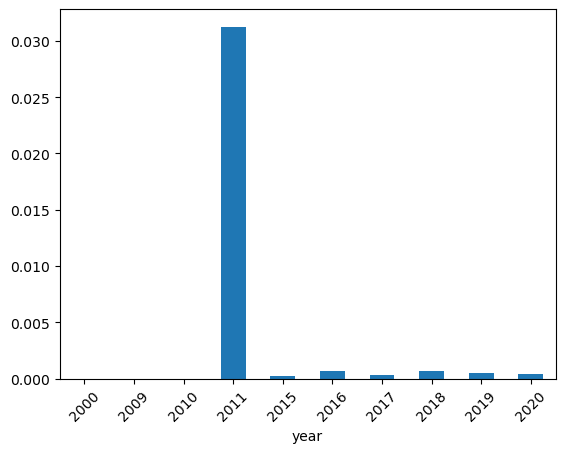

In [36]:
faults_full.groupby('year')['derate_flag'].mean().plot.bar(rot=45);

We see that there were no derates in our data until 2011; the rate of derates in our data spiked in 2011, and stayed at a low but non-zero level from 2015-2020. All yearly rates are very low, with the peak around 3%.

In [37]:
faults_full.shape

(1055071, 42)

In [38]:
# Finally, we'll drop rows that are within 12 hours after a derate, since the diagnostics will likely look similar to a derate 

derate_events = faults_full[faults_full['derate_flag'] == 1][['EquipmentID', 'EventTimeStamp']].rename(columns={'EventTimeStamp': 'last_derate_time'}).copy()

# Merge using merge_asof (time column must be sorted first)
faults_full = faults_full.sort_values(
    ['EventTimeStamp', 'EquipmentID']
).reset_index(drop=True)

derate_events = derate_events.sort_values(
    ['last_derate_time', 'EquipmentID']
).reset_index(drop=True)

# Match each row to the most recent previous derate
faults_full = pd.merge_asof(
    faults_full,
    derate_events,
    left_on='EventTimeStamp',
    right_on='last_derate_time',
    by='EquipmentID',
    direction='backward'
)

# Filter out rows within 12 hours of a derate
faults_full = faults_full[faults_full['EventTimeStamp'] > faults_full['last_derate_time'] + pd.Timedelta(hours=12)]

# Drop derate_flag since it was only needed for EDA, as well as last derate time
faults_full = faults_full.drop(columns=['derate_flag','last_derate_time'])

In [39]:
faults_full.shape

(109820, 41)

In [40]:
(1055071-109820)/1055071

0.8959122182298632

We retain 89% of our dataset after dropping rows within 12 hours after a derate event.

# Data Pre-Processing

In [41]:
# Convert 'object' columns into numerical and string datatypes, as appropriate
numeric_features = ['faults_in_last_hr','DistanceLtd','EngineTimeLtd','FuelLtd','activeTransitionCount','TurboBoostPressure','AcceleratorPedal','BarometricPressure','CruiseControlSetSpeed','EngineCoolantTemperature','EngineLoad','EngineOilPressure','EngineOilTemperature','EngineRpm','FuelLevel','FuelRate','FuelTemperature','IntakeManifoldTemperature','Speed','SwitchedBatteryVoltage','Throttle']
for feature in numeric_features:
    faults_full[feature] = faults_full[feature].astype('float32')

categorical_features = ['spn','fmi','LampStatus','active','CruiseControlActive','IgnStatus','ParkingBrake','year','weekday','summer','daytime','nighttime','month','day','hour']
for feature in categorical_features:
    faults_full[feature] = faults_full[feature].astype('str')

In [42]:
# We'll apply a forward fill to deal with null values in any columns that represent a running count
ffill_features = ['DistanceLtd', 'EngineTimeLtd', 'FuelLtd']
for feature in ffill_features:
    faults_full[feature] = faults_full.groupby('EquipmentID')[feature].ffill().bfill()

In [43]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    # Applying a simple imputer to fill missing values
    ("imputer", IterativeImputer(random_state=0, verbose=2)),
    # Applying a MaxAbsScaler (better than StandardScaler for sparse inputs or inputs that are not normally distributed)
    ("scaler", MaxAbsScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all the transformations into 1 preprocessor
# Using ColumnTransformer to select specific columns and apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

pipe = Pipeline(
    steps=[("preprocessor", preprocessor)]
)

In [44]:
# Anything before 1/1/2019 is our training/validation data
train_data = faults_full[~(faults_full['EventTimeStamp'].dt.date >= pd.to_datetime('2019-01-01').date())].reset_index()

# Converting EventTimeStamp to datetime
train_data['EventTimeStamp'] = pd.to_datetime(train_data['EventTimeStamp'])

# Anything after 1/1/2019 is the test data
test_data = faults_full[faults_full['EventTimeStamp'].dt.date >= pd.to_datetime('2019-01-01').date()]

In [45]:
def calculate_cost_savings(evaluation_df):
    """
    Returns the amount of money we are saving Big G by implementing our model
    """

    evaluation_df['date']= pd.to_datetime(evaluation_df['EventTimeStamp']).dt.date
    model_cost_total = evaluation_df.groupby(['EquipmentID', 'date']).agg({'actual_derate': 'max', 'pred_derate': 'max'}).sort_values('actual_derate', ascending=False)
    
    # Create a for loop to calculate cost based on formulas
    total_cost_list = []
    for row in range(len(model_cost_total)):
        eval_row = model_cost_total.iloc[row]
        if (eval_row['actual_derate'] == 0) & (eval_row['pred_derate'] == 1):
            total_cost_list.append(-500)
        elif (eval_row['actual_derate'] == 1) & (eval_row['pred_derate'] == 1):
            total_cost_list.append(4000)
        else:
            total_cost_list.append(0)
        
    return np.sum(total_cost_list)

# Model Cross Validation

Here, we'll split our data using 5-fold validation and apply the pre-processor pipeline (scaling and filling in missing values). 

Once we have our pre-processed cross-validation datasets, we'll fit a model to each of the training sets and evaluate its effectiveness via the corresponding validation set. 

Good article here: https://www.geeksforgeeks.org/machine-learning/k-fold-cross-validation-in-machine-learning/

Since the first few years in our dataset have zero derate events, we'll contruct our folds so that each has the same frequency of events leading up to a derate, rather than splitting the data into 5 equally-sized parts.

In [46]:
# Initialize a dataframe to store model evaluation metrics 
model_evaluation_results = pd.DataFrame(columns=['fold', 'time_window', 'upweight', 'oversample', 'f-beta', 'ROC-AUC', 'precision', 'recall', 'false positives', 'true positives', 'cost_savings']) 

targets = ['derate_6_hr','derate_12_hr','derate_24_hr'] 

for target in targets:     
    print(f'TARGET: {target}')      

    # Narrow down to just the positive class
    positive_class = train_data[train_data[target]==1][[target]]

    # Split the index of the positive class into 5 equal parts
    groups, cutoffs = pd.qcut(positive_class.index, q=5, labels=False, retbins=True)

    # Split the training set based on those indices, so that each part has the same frequency of the positive class
    parts = np.array_split(train_data, cutoffs[1:-1].astype(int))
    
    for strategy in ('upweight','oversample'):         
        print(f'BALANCING STRATEGY: {strategy}')    

        # Initialize an empty list to keep track of the training data
        train_parts = []

        for i in range(4):
            # Define train and validation sets
            
            # The training set is every part up to the current index combined
            train_parts = [parts[j] for j in range(4) if j <= i]
            train_set = pd.concat(train_parts)
            
            # The validation set is always the part corresponding to the next index
            val_set = parts[i + 1]
        
            # Split into x (features) and y (target) 
            X_train = train_set[[col for col in train_set.columns if not col.startswith('derate') and col not in ('EquipmentID','EventTimeStamp')]] 
            y_train = train_set[target]
                     
            X_val = val_set[[col for col in train_set.columns if not col.startswith('derate') and col not in ('EquipmentID','EventTimeStamp')]] 
            y_val = val_set[target] 
        
            # Preprocessing: Fit and transform the train set
            X_train = pipe.fit_transform(X_train)
            
            # Preprocessing: Transform the validation set 
            X_val = pipe.transform(X_val)
                 
            if strategy == 'upweight': 
                upweight = 1 
                oversample = 0 
                classes = np.unique(y_train)
                weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
                weight_dict = {cls: weight for cls, weight in zip(classes, weights)}
                
                # Pass weights via class_weight 
                model = XGBClassifier(n_estimators=1000, objective='multi:softprob', num_class=3, n_jobs=-1).fit(
                    X_train, y_train, sample_weight=np.vectorize(weight_dict.get)(y_train)
                )
            else: 
                upweight = 0 
                oversample = 1 
                # Apply SMOTE oversampling to deal with imbalanced classes 
                smote = SMOTE(random_state=321) 
                X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) 
                                
                # Initialize and fit a model 
                model = XGBClassifier(n_estimators=1000, objective='multi:softprob', num_class=3, n_jobs=-1).fit(X_train_smote, y_train_smote) 
                         
            # Generate predictions on the validation set 
            y_pred = model.predict(X_val) 

            # Generate predicted probabiliites
            y_pred_proba = model.predict_proba(X_val)
                 
            # Prepare a dataframe to assess cost savings 
            evaluation_df = val_set[['EquipmentID','EventTimeStamp']].copy() 
            evaluation_df['pred_derate'] = y_pred 
            evaluation_df['actual_derate'] = y_val 
            evaluation_df['pred_derate'] = evaluation_df['pred_derate'].astype(int) 
            evaluation_df['actual_derate'] = evaluation_df['actual_derate'].astype(int) 
                     
            # Calculate metrics for this specific fold
            cost_savings = calculate_cost_savings(evaluation_df) 
            prec = precision_score(y_val, y_pred, average='weighted') 
            rec = recall_score(y_val, y_pred, average='weighted') 
            fbeta = fbeta_score(y_val, y_pred, beta=8, average='weighted') 
            roc_auc = roc_auc_score(y_val, y_pred_proba, multi_class='ovo', labels=[0,1,2])
            
            cm = confusion_matrix(y_val, y_pred) 
            tp = cm[1,1]
            fp = cm[0,1]
             
            # Append 1 row per fold to the results dataframe
            model_evaluation_results.loc[len(model_evaluation_results)] = [i+1, target, upweight, oversample, fbeta, roc_auc, prec, rec, fp, tp, cost_savings]

TARGET: derate_6_hr
BALANCING STRATEGY: upweight
[IterativeImputer] Completing matrix with shape (9368, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.08
[IterativeImputer] Change: 8149.8466796875, scaled tolerance: 581.7481689453125 
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.18
[IterativeImputer] Change: 951.47314453125, scaled tolerance: 581.7481689453125 


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


[IterativeImputer] Ending imputation round 3/10, elapsed time 0.26
[IterativeImputer] Change: 281.0830078125, scaled tolerance: 581.7481689453125 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (7491, 21)
[IterativeImputer] Ending imputation round 1/3, elapsed time 0.01
[IterativeImputer] Ending imputation round 2/3, elapsed time 0.01
[IterativeImputer] Ending imputation round 3/3, elapsed time 0.01
[IterativeImputer] Completing matrix with shape (16859, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.10
[IterativeImputer] Change: 2718.45263671875, scaled tolerance: 618.2691650390625 
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.19
[IterativeImputer] Change: 472.700439453125, scaled tolerance: 618.2691650390625 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (24275, 21)
[IterativeImputer] Ending imputation round 1/2, elapsed time 0.02
[Itera

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


BALANCING STRATEGY: oversample
[IterativeImputer] Completing matrix with shape (9368, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.19
[IterativeImputer] Change: 8149.8466796875, scaled tolerance: 581.7481689453125 
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.36
[IterativeImputer] Change: 951.47314453125, scaled tolerance: 581.7481689453125 
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.50
[IterativeImputer] Change: 281.0830078125, scaled tolerance: 581.7481689453125 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (7491, 21)
[IterativeImputer] Ending imputation round 1/3, elapsed time 0.00
[IterativeImputer] Ending imputation round 2/3, elapsed time 0.00
[IterativeImputer] Ending imputation round 3/3, elapsed time 0.01
[IterativeImputer] Completing matrix with shape (16859, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.19
[IterativeImputer] Change: 271

...

TARGET: derate_12_hr
BALANCING STRATEGY: upweight
[IterativeImputer] Completing matrix with shape (10245, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.11
[IterativeImputer] Change: 3199.386474609375, scaled tolerance: 587.3948974609375 
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.26
[IterativeImputer] Change: 591.1918334960938, scaled tolerance: 587.3948974609375 
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.42
[IterativeImputer] Change: 295.079345703125, scaled tolerance: 587.3948974609375 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (6615, 21)
[IterativeImputer] Ending imputation round 1/3, elapsed time 0.00
[IterativeImputer] Ending imputation round 2/3, elapsed time 0.00
[IterativeImputer] Ending imputation round 3/3, elapsed time 0.01
[IterativeImputer] Completing matrix with shape (16860, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.13
[Ite

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


[IterativeImputer] Ending imputation round 2/10, elapsed time 0.24
[IterativeImputer] Change: 889.71923828125, scaled tolerance: 582.6834106445312 
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.39
[IterativeImputer] Change: 360.728515625, scaled tolerance: 582.6834106445312 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (7225, 21)
[IterativeImputer] Ending imputation round 1/3, elapsed time 0.00
[IterativeImputer] Ending imputation round 2/3, elapsed time 0.01
[IterativeImputer] Ending imputation round 3/3, elapsed time 0.01
[IterativeImputer] Completing matrix with shape (16788, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.14
[IterativeImputer] Change: 2673.891357421875, scaled tolerance: 617.951416015625 
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.37
[IterativeImputer] Change: 470.5107421875, scaled tolerance: 617.951416015625 
[IterativeImputer] Early stopping criteri

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[IterativeImputer] Completing matrix with shape (25709, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.24
[IterativeImputer] Change: 3674.4814453125, scaled tolerance: 636.4963989257812 
[IterativeImputer] Ending imputation round 2/10, elapsed time 0.47
[IterativeImputer] Change: 840.1498413085938, scaled tolerance: 636.4963989257812 
[IterativeImputer] Ending imputation round 3/10, elapsed time 0.81
[IterativeImputer] Change: 307.606689453125, scaled tolerance: 636.4963989257812 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (26387, 21)
[IterativeImputer] Ending imputation round 1/3, elapsed time 0.02
[IterativeImputer] Ending imputation round 2/3, elapsed time 0.05
[IterativeImputer] Ending imputation round 3/3, elapsed time 0.09
[IterativeImputer] Completing matrix with shape (52096, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.31
[IterativeImputer] Change: 2221.458984375, scaled toler

In [47]:
model_evaluation_results

,fold,time_window,upweight,oversample,f-beta,ROC-AUC,precision,recall,false positives,true positives,cost_savings
0,1,derate_6_hr,1,0,0.981234,0.558637,0.976566,0.981311,11,2,-2000
1,2,derate_6_hr,1,0,0.950056,0.603190,0.991892,0.949454,81,0,-10000
2,3,derate_6_hr,1,0,0.987231,0.616369,0.982222,0.987313,1,0,0
3,4,derate_6_hr,1,0,0.995709,0.598593,0.991732,0.995771,0,0,0
4,1,derate_6_hr,0,1,0.982279,0.554917,0.975925,0.982379,36,1,-12500
5,2,derate_6_hr,0,1,0.973256,0.570431,0.991476,0.972976,26,0,-500
6,3,derate_6_hr,0,1,0.989511,0.612116,0.981972,0.989657,0,0,0
7,4,derate_6_hr,0,1,0.995781,0.608301,0.991707,0.995845,0,0,0
8,1,derate_12_hr,1,0,0.977884,0.562930,0.966062,0.978080,19,2,-2500
9,2,derate_12_hr,1,0,0.954193,0.606375,0.989950,0.953679,273,9,-28000


In [48]:
# Average metrics across all folds
summary_df = model_evaluation_results.groupby(
    ['time_window', 'upweight', 'oversample']
).mean().reset_index().drop(columns='fold')

summary_df

,time_window,upweight,oversample,f-beta,ROC-AUC,precision,recall,false positives,true positives,cost_savings
0,derate_12_hr,0,1,0.982280,0.576814,0.980901,0.982320,45.25,1.75,-3250.0
1,derate_12_hr,1,0,0.975569,0.576039,0.980197,0.975514,76.00,3.00,-7625.0
2,derate_24_hr,0,1,0.958104,0.612084,0.974332,0.958004,326.25,18.50,-8250.0
3,derate_24_hr,1,0,0.947320,0.586820,0.972518,0.947080,425.00,19.00,-16875.0
4,derate_6_hr,0,1,0.985207,0.586441,0.985270,0.985214,15.50,0.25,-3250.0
5,derate_6_hr,1,0,0.978557,0.594197,0.985603,0.978462,23.25,0.50,-3000.0


# Model Testing

Seeing how well the model does on our "real-world" data. In our k-fold validation, the 2-6 hour time window combined with balancing class weights performed the best, so that's what we'll use here. 

In [49]:
# Redefine train set since we've already transformed it during k-fold
train_set = faults_full[~(faults_full['EventTimeStamp'].dt.date >= pd.to_datetime('2019-01-01').date())]

# Converting EventTimeStamp to datetime
train_set['EventTimeStamp'] = pd.to_datetime(train_set['EventTimeStamp'])

# Anything after 1/1/2019 is the test data
test_set = faults_full[faults_full['EventTimeStamp'].dt.date >= pd.to_datetime('2019-01-01').date()]

# Initialize a dataframe to store model evaluation metrics
model_evaluation_results = pd.DataFrame(columns=['time_window', 'upweight', 'oversample', 'f-beta', 'ROC-AUC', 'precision', 'recall', 'false positives', 'true positives', 'cost_savings'])

# We'll use the 6 hour time window for our target since it performed the best during k-fold validation
target = 'derate_6_hr'

# Split into x (features) and y (target)
X_train = train_set[[col for col in train_set.columns if not col.startswith('derate') and col not in ('EquipmentID','EventTimeStamp')]]
y_train = train_set[target]

X_test = test_set[[col for col in train_set.columns if not col.startswith('derate') and col not in ('EquipmentID','EventTimeStamp')]]
y_test = test_set[target]

# Fit and transform the train set using our preprocessing pipeline
X_train = pipe.fit_transform(X_train)

# Transform the test set
X_test = pipe.transform(X_test)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weight_dict = {cls: weight for cls, weight in zip(classes, weights)}

# Pass weights via class_weight 
model = XGBClassifier(n_estimators=1000, objective='multi:softprob', num_class=3, n_jobs=-1).fit(
    X_train, y_train, sample_weight=np.vectorize(weight_dict.get)(y_train)
)

# Generate predictions on the test set using the model
y_pred = model.predict(X_test)

# Generate predicted probabiliites
y_pred_proba = model.predict_proba(X_test)

# Prepare a dataframe to assess cost savings
evaluation_df = test_set[['EquipmentID','EventTimeStamp']].copy()
evaluation_df['pred_derate']= y_pred
evaluation_df['actual_derate']= y_test

# Calculate true positives and false positives 
cm = confusion_matrix(y_test, y_pred)
tp = cm[1,1]
fp = cm[0,1]

# Append results to model_evaluation_results
model_evaluation_results.loc[len(model_evaluation_results)] = [target, 1, 0, fbeta_score(y_test, y_pred, beta=8, average='weighted'), roc_auc_score(y_test, y_pred_proba, multi_class='ovo', labels=[0,1,2]), precision_score(y_test, y_pred, average='weighted'), recall_score(y_test, y_pred, average='weighted'), fp, tp, calculate_cost_savings(evaluation_df)]

# Print model evaluation results
model_evaluation_results

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_45816/2918007089.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set['EventTimeStamp'] = pd.to_datetime(train_set['EventTimeStamp'])


[IterativeImputer] Completing matrix with shape (96312, 21)
[IterativeImputer] Ending imputation round 1/10, elapsed time 0.54
[IterativeImputer] Change: 1380.801025390625, scaled tolerance: 636.4963989257812 
[IterativeImputer] Ending imputation round 2/10, elapsed time 1.10
[IterativeImputer] Change: 356.9273681640625, scaled tolerance: 636.4963989257812 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (13508, 21)
[IterativeImputer] Ending imputation round 1/2, elapsed time 0.01
[IterativeImputer] Ending imputation round 2/2, elapsed time 0.01


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,time_window,upweight,oversample,f-beta,ROC-AUC,precision,recall,false positives,true positives,cost_savings
0,derate_6_hr,1,0,0.993018,0.566257,0.986864,0.993115,0,0,0


# Model Interpretability/Explainability:

In [50]:
# Printing top features by permutation importance
f1_scorer = make_scorer(f1_score, zero_division=0, average='weighted')
pd.DataFrame({
    'variable': pipe.get_feature_names_out(),
    'importance': permutation_importance(model, pd.DataFrame(X_test).sample(random_state=0,n=2000), pd.DataFrame(y_test).sample(random_state=0,n=2000), random_state = 0, scoring=f1_scorer)['importances_mean']
}).sort_values('importance', ascending = False)

,variable,importance
385,hour_7,0.00025
3,FuelLtd,0.00005
12,EngineOilTemperature,0.00005
0,faults_in_last_hr,0.00000
255,spn_805,0.00000
...,...,...
128,spn_3697,0.00000
127,spn_3610,0.00000
126,spn_3605,0.00000
125,spn_36017,0.00000


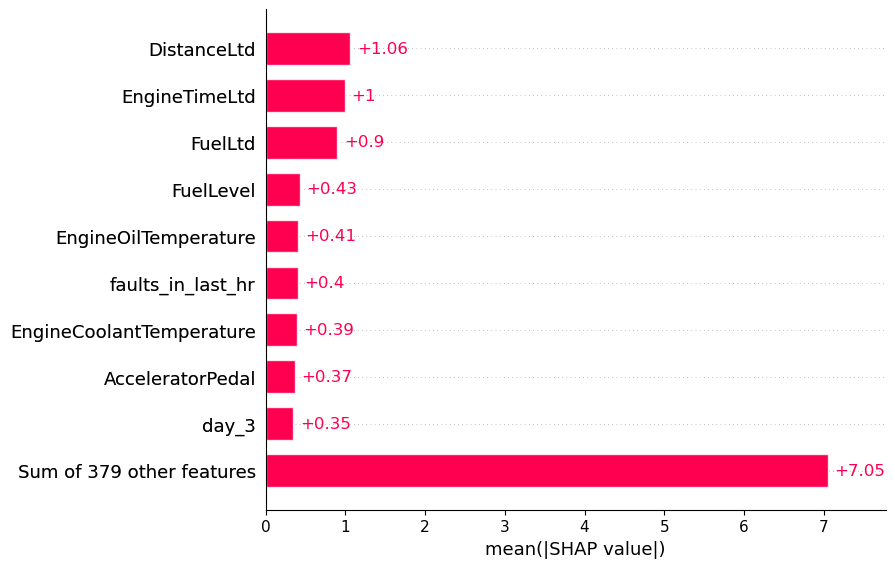

In [51]:
# Plotting features by average shap score
explainer = shap.TreeExplainer(model)
explanation = explainer(X_test)
explanation.feature_names = pipe.get_feature_names_out()
# Visualize feature impact for the middle class (the class we are trying to predict)
shap.plots.bar(explanation[:, :, 1])

In [52]:
explanation[:, :, 1]

.values =
array([[ 0.43084073, -0.24306673, -2.406329  , ..., -0.05254377,
        -0.00246431,  0.03962083],
       [ 0.40462387, -0.401704  , -1.8942386 , ..., -0.05790913,
        -0.00390422,  0.04266325],
       [-0.70076627, -1.0269371 , -1.0074337 , ..., -0.03912137,
         0.01722804,  0.04227516],
       ...,
       [ 0.3919042 , -1.1792715 , -0.10544419, ..., -0.03904432,
         0.00902384,  0.0061238 ],
       [ 0.4982026 , -1.1641586 , -0.3155169 , ..., -0.0863238 ,
        -0.02139695,  0.03466702],
       [ 0.4990827 , -1.1635363 , -0.31889018, ..., -0.07546197,
        -0.02139695,  0.03466702]], dtype=float32)

.base_values =
array([0.35626626, 0.35626626, 0.35626626, ..., 0.35626626, 0.35626626,
       0.35626626], dtype=float32)

.data =
array([[0.00285714, 0.76797897, 0.09971628, ..., 0.        , 0.        ,
        0.        ],
       [0.00285714, 0.76797897, 0.09971628, ..., 0.        , 0.        ,
        0.        ],
       [0.00857143, 0.69216782, 0.07804663